In [41]:
import sqlite3
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, cross_val_score
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
# basically just need to clean the dataset and vectorize the text and title features
stop_words = set(stopwords.words("english"))

In [3]:
# after learning about Word2Vec in class, I'm considering using it over TF-IDF, or maybe pitting the two against each other
# I personally think in relation to fake news vs real news, the use of specific words rather than semantic meaning/relationships
# is what is more important, so I think TF-IDF would serve as the better model, but I would like to try both and compare 
# evaluation metrics of both and perform model selection based on them (basically see if my hypothesis is right or not)
conn = sqlite3.connect("news.db")
df = pd.read_sql_query("""
    SELECT a.article_id, a.title, a.text, l.label
    FROM Articles a
    JOIN Labels l ON a.article_id = l.article_id
""", conn)
df.head()

,article_id,title,text,label
0,1,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,fake
1,2,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,fake
2,3,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",fake
3,4,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",fake
4,5,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,fake


In [4]:
print(f"Before cleaning: {len(df)} articles")
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = " ".join([w for w in text.split() if w not in stop_words and len(w) > 2])
    return text

df["title_clean"] = df["title"].apply(clean_text)
df["text_clean"] = df["text"].apply(clean_text)
df = df[df["text_clean"].str.len() > 50]
df = df[df["title_clean"].str.len() > 5]
df[["title", "title_clean", "text", "text_clean"]].head(3)
print(f"After cleaning: {len(df)} articles")
print(f"Removed: {44898 - len(df)} articles")
# don't want to mess with original data

Before cleaning: 44898 articles
After cleaning: 43965 articles
Removed: 933 articles


In [5]:
# chose to use TF-IDF and Word2Vec on title and text separately
# TF-IDF Preprocessing
title_vectorizer = TfidfVectorizer(max_features=5000)
text_vectorizer = TfidfVectorizer(max_features=5000)

title_tfidf = title_vectorizer.fit_transform(df["title_clean"])
text_tfidf = text_vectorizer.fit_transform(df["text_clean"])

print(f"Title TF-IDF shape: {title_tfidf.shape}")
print(f"Text TF-IDF shape: {text_tfidf.shape}")
# number of articles, number of words/features (5000-dimensional vector)
# basically building vocabulary

Title TF-IDF shape: (43965, 5000)
Text TF-IDF shape: (43965, 5000)


In [6]:
X = hstack([title_tfidf, text_tfidf]) # scipy.sparse.hstack() used here because TF-IDF matrices are sparse (have lots of zeroes)
y = df["label"]

print(f"Combined feature matrix shape: {X.shape}")
print(f"Label distribution:\n{y.value_counts()}")

Combined feature matrix shape: (43965, 10000)
Label distribution:
label
fake    22549
real    21416
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 35172
Test set size: 8793


In [8]:
cleaned_df = df[["article_id", "title_clean", "text_clean", "label"]]
cleaned_df.to_sql("Articles_Cleaned", conn, if_exists="replace", index=False)

conn.commit()

In [9]:
# Word2Vec Preprocessing
df = pd.read_sql_query("SELECT article_id, title_clean, text_clean, label FROM Articles_Cleaned", conn)
print(f"Loaded {len(df)} cleaned articles.")
df.head()

Loaded 43965 cleaned articles.


,article_id,title_clean,text_clean,label
0,1,donald trump sends embarrassing new years eve ...,donald trump wish americans happy new year lea...,fake
1,2,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,fake
2,3,sheriff david clarke becomes internet joke thr...,friday revealed former milwaukee sheriff david...,fake
3,4,trump obsessed even obamas name coded website ...,christmas day donald trump announced would bac...,fake
4,5,pope francis called donald trump christmas speech,pope francis used annual christmas day message...,fake


In [10]:
df["title_tokens"] = df["title_clean"].apply(lambda x: x.split())
df["text_tokens"] = df["text_clean"].apply(lambda x: x.split())

all_tokens = df["title_tokens"].tolist() + df["text_tokens"].tolist()

print(f"Total token sequences: {len(all_tokens)}")
print(f"Example title tokens: {df['title_tokens'][0]}")
print(f"Example text tokens: {df['text_tokens'][0][:20]}")

Total token sequences: 87930
Example title tokens: ['donald', 'trump', 'sends', 'embarrassing', 'new', 'years', 'eve', 'message', 'disturbing']
Example text tokens: ['donald', 'trump', 'wish', 'americans', 'happy', 'new', 'year', 'leave', 'instead', 'give', 'shout', 'enemies', 'haters', 'dishonest', 'fake', 'news', 'media', 'former', 'reality', 'show']


In [11]:
w2v_model = Word2Vec(
    sentences=all_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5
)
# training word2vec model with context of articles
print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")
print(f"Example vector for 'trump': {w2v_model.wv['trump'][:10]}")

Word2Vec vocabulary size: 120193
Example vector for 'trump': [-0.43902498  2.3282096  -2.2884862   3.298329    1.4091183   1.2590147
 -0.8716099  -1.7351005   1.178317    0.979362  ]


In [12]:
def article_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

df["title_w2v"] = df["title_tokens"].apply(lambda x: article_vector(x, w2v_model))
df["text_w2v"] = df["text_tokens"].apply(lambda x: article_vector(x, w2v_model))
# for each article, takes article's list of tokens and averages their vectors
# each row represents average vector for an article's title and text as a numpy array
print(f"Example title vector shape: {df['title_w2v'][0].shape}")

Example title vector shape: (100,)


In [13]:
print(df.columns)
title_w2v_matrix = np.vstack(df["title_w2v"].values)
text_w2v_matrix = np.vstack(df["text_w2v"].values)

X_w2v = np.hstack([title_w2v_matrix, text_w2v_matrix]) # np.hstack() used here because Word2Vec produces dense matrices
y_w2v = df["label"]

print(f"Word2Vec feature matrix shape: {X_w2v.shape}")

Index(['article_id', 'title_clean', 'text_clean', 'label', 'title_tokens',
       'text_tokens', 'title_w2v', 'text_w2v'],
      dtype='object')
Word2Vec feature matrix shape: (43965, 200)


In [14]:
X_w2v_train, X_w2v_test, y_w2v_train, y_w2v_test = train_test_split(X_w2v, y_w2v, test_size=0.2, random_state=42)

print(f"Training set size: {X_w2v_train.shape[0]}")
print(f"Test set size: {X_w2v_test.shape[0]}")

Training set size: 35172
Test set size: 8793


In [17]:
# TF-IDF Logistic Regression model training and testing
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test)
print("TF-IDF + Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr_tfidf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_tfidf, pos_label='fake'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr_tfidf, pos_label='fake'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr_tfidf, pos_label='fake'):.4f}")
# training results are too good - could imply overfitting from data being too clean?

TF-IDF + Logistic Regression Results:
Accuracy:  0.9949
Precision: 0.9967
Recall:    0.9933
F1 Score:  0.9950


In [19]:
# TF-IDF Naive Bayes model training and testing
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test)
print("TF-IDF + Naive Bayes Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb_tfidf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb_tfidf, pos_label='fake'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb_tfidf, pos_label='fake'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_nb_tfidf, pos_label='fake'):.4f}")
# Naive Bayes performed well but still worse than Logistic Regression, possibly because Naive Bayes assumes feature independence,
# while Logistic Regression doesn't, learning relationships between words

TF-IDF + Naive Bayes Results:
Accuracy:  0.9500
Precision: 0.9490
Recall:    0.9536
F1 Score:  0.9513


In [20]:
# Word2Vec Logistic Regression model training and testing
lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_w2v_train, y_w2v_train)
y_pred_lr_w2v = lr_w2v.predict(X_w2v_test)
print("Word2Vec + Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_w2v_test, y_pred_lr_w2v):.4f}")
print(f"Precision: {precision_score(y_w2v_test, y_pred_lr_w2v, pos_label='fake'):.4f}")
print(f"Recall:    {recall_score(y_w2v_test, y_pred_lr_w2v, pos_label='fake'):.4f}")
print(f"F1 Score:  {f1_score(y_w2v_test, y_pred_lr_w2v, pos_label='fake'):.4f}")
# confirms hypothesis that TF-IDF outperforms Word2Vec, at least for Logistic Regression Model

Word2Vec + Logistic Regression Results:
Accuracy:  0.9748
Precision: 0.9775
Recall:    0.9731
F1 Score:  0.9753


In [22]:
'''
nb_w2v = MultinomialNB()
nb_w2v.fit(X_w2v_train, y_w2v_train)
y_pred_nb_w2v = nb_w2v.predict(X_w2v_test)
print("Word2Vec + Naive Bayes Results:")
print(f"Accuracy: {accuracy_score(y_w2v_test, y_pred_nb_w2v):.4f}")
print(f"Precision: {precision_score(y_w2v_test, y_pred_nb_w2v, pos_label='fake'):.4f}")
print(f"Recall: {recall_score(y_w2v_test, y_pred_nb_w2v, pos_label='fake'):.4f}")
print(f"Score: {f1_score(y_w2v_test, y_pred_nb_w2v, pos_label='fake'):.4f}")
'''
# unexpected error: ValueError: Negative values in data passed to MultinomialNB (input X)
# apparently, NB cannot process negative values, and while TF-IDF only produces positive values (word frequencies), Word2Vec can
# produce negative values because the values are in relation to other words
# so a Multinomial Naive Bayes model (made for discrete data) for Word2Vec cannot be made --> must use Gaussian NB

'\nnb_w2v = MultinomialNB()\nnb_w2v.fit(X_w2v_train, y_w2v_train)\ny_pred_nb_w2v = nb_w2v.predict(X_w2v_test)\nprint("Word2Vec + Naive Bayes Results:")\nprint(f"Accuracy: {accuracy_score(y_w2v_test, y_pred_nb_w2v):.4f}")\nprint(f"Precision: {precision_score(y_w2v_test, y_pred_nb_w2v, pos_label=\'fake\'):.4f}")\nprint(f"Recall: {recall_score(y_w2v_test, y_pred_nb_w2v, pos_label=\'fake\'):.4f}")\nprint(f"Score: {f1_score(y_w2v_test, y_pred_nb_w2v, pos_label=\'fake\'):.4f}")\n'

In [24]:
nb_w2v = GaussianNB()
nb_w2v.fit(X_w2v_train, y_w2v_train)
y_pred_nb_w2v = nb_w2v.predict(X_w2v_test)

print("Word2Vec + Gaussian Naive Bayes Results:")
print(f"Accuracy:  {accuracy_score(y_w2v_test, y_pred_nb_w2v):.4f}")
print(f"Precision: {precision_score(y_w2v_test, y_pred_nb_w2v, pos_label='fake'):.4f}")
print(f"Recall:    {recall_score(y_w2v_test, y_pred_nb_w2v, pos_label='fake'):.4f}")
print(f"F1 Score:  {f1_score(y_w2v_test, y_pred_nb_w2v, pos_label='fake'):.4f}")
# I guess these weaker results mean the vectors don't necessarily follow Gaussian distribution very well

Word2Vec + Gaussian Naive Bayes Results:
Accuracy:  0.8876
Precision: 0.9007
Recall:    0.8775
F1 Score:  0.8889


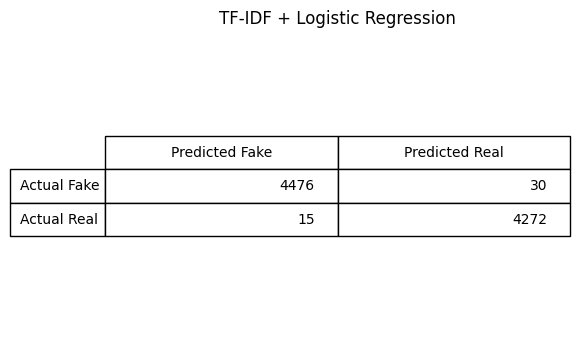

In [37]:
# TF-IDF Logistic Regression model confusion matrix
cm = confusion_matrix(y_test, y_pred_lr_tfidf, labels=["fake", "real"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
table = ax.table(
    cellText=cm,
    rowLabels=["Actual Fake", "Actual Real"],
    colLabels=["Predicted Fake", "Predicted Real"],
    loc="center"
)
table.scale(1, 2)
ax.set_title("TF-IDF + Logistic Regression")
plt.show()

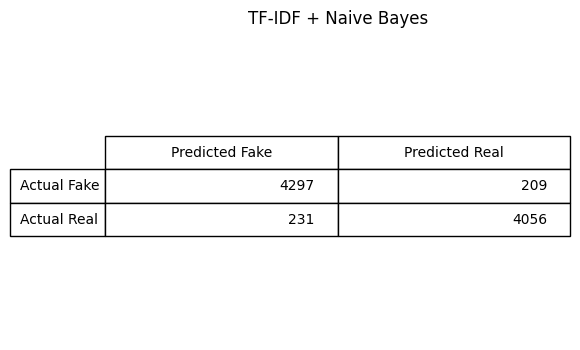

In [38]:
# TF-IDF Naive Bayes model confusion matrix
cm = confusion_matrix(y_test, y_pred_nb_tfidf, labels=["fake", "real"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
table = ax.table(
    cellText=cm,
    rowLabels=["Actual Fake", "Actual Real"],
    colLabels=["Predicted Fake", "Predicted Real"],
    loc="center"
)
table.scale(1, 2)
ax.set_title("TF-IDF + Naive Bayes")
plt.show()

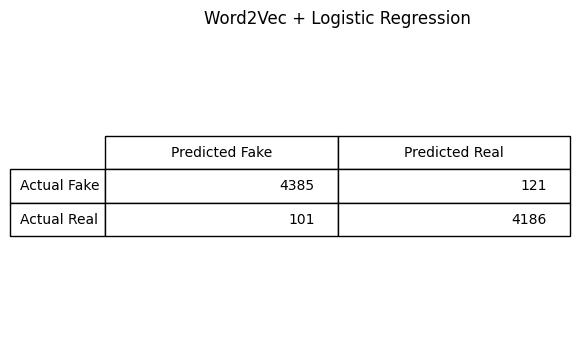

In [39]:
# Word2Vec Logistic Regression Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr_w2v, labels=["fake", "real"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
table = ax.table(
    cellText=cm,
    rowLabels=["Actual Fake", "Actual Real"],
    colLabels=["Predicted Fake", "Predicted Real"],
    loc="center"
)
table.scale(1, 2)
ax.set_title("Word2Vec + Logistic Regression")
plt.show()

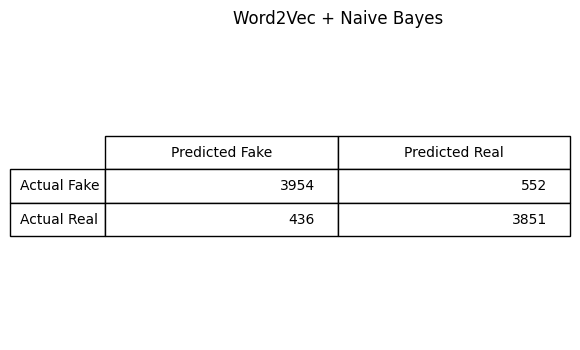

In [40]:
# Word2Vec Naive Bayes confusion matrix
cm = confusion_matrix(y_test, y_pred_nb_w2v, labels=["fake", "real"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
table = ax.table(
    cellText=cm,
    rowLabels=["Actual Fake", "Actual Real"],
    colLabels=["Predicted Fake", "Predicted Real"],
    loc="center"
)
table.scale(1, 2)
ax.set_title("Word2Vec + Naive Bayes")
plt.show()

In [42]:
models = [
    (LogisticRegression(max_iter=1000), X, y, "TF-IDF + Logistic Regression"),
    (MultinomialNB(), X, y, "TF-IDF + Naive Bayes"),
    (LogisticRegression(max_iter=1000), X_w2v, y_w2v, "Word2Vec + Logistic Regression"),
    (GaussianNB(), X_w2v, y_w2v, "Word2Vec + Gaussian Naive Bayes")
]

for model, features, labels, name in models:
    scores = cross_val_score(model, features, labels, cv=5, scoring="accuracy")
    print(f"{name}:")
    print(f"  Fold Scores: {scores.round(4)}")
    print(f"  Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print()

TF-IDF + Logistic Regression:
  Fold Scores: [0.992  0.9877 0.982  0.9848 0.9859]
  Mean Accuracy: 0.9865 (+/- 0.0033)

TF-IDF + Naive Bayes:
  Fold Scores: [0.9321 0.9212 0.8812 0.9393 0.9379]
  Mean Accuracy: 0.9223 (+/- 0.0215)

Word2Vec + Logistic Regression:
  Fold Scores: [0.9728 0.9761 0.9583 0.9649 0.9677]
  Mean Accuracy: 0.9680 (+/- 0.0062)

Word2Vec + Gaussian Naive Bayes:
  Fold Scores: [0.915  0.8968 0.8566 0.8509 0.8609]
  Mean Accuracy: 0.8761 (+/- 0.0253)



In [47]:
# since I am now skeptical of the dataset itself, I will test my models on new data to see how they perform (make sure they
# aren't overfit)
def predict_article(title, text):
    # Clean the inputs
    title_clean = clean_text(title)
    text_clean = clean_text(text)
    
    # TF-IDF prediction
    title_vec = title_vectorizer.transform([title_clean])
    text_vec = text_vectorizer.transform([text_clean])
    combined = hstack([title_vec, text_vec])
    tfidf_pred = lr_tfidf.predict(combined)[0]
    
    # Word2Vec prediction
    title_tokens = title_clean.split()
    text_tokens = text_clean.split()
    title_w2v_vec = article_vector(title_tokens, w2v_model).reshape(1, -1)
    text_w2v_vec = article_vector(text_tokens, w2v_model).reshape(1, -1)
    combined_w2v = np.hstack([title_w2v_vec, text_w2v_vec])
    w2v_pred = lr_w2v.predict(combined_w2v)[0]
    
    print(f"TF-IDF + Logistic Regression: {tfidf_pred}")
    print(f"Word2Vec + Logistic Regression: {w2v_pred}")


In [48]:
# real Reuters article about recent correspondence dinner incident
title = "Trump, Secret Service director say agent at dinner not shot by friendly fire"
text = """
WASHINGTON, April 30 (Reuters) - U.S. President Donald Trump and the head of the Secret Service said on Thursday the federal agent ‌injured during the attack at the White House Correspondents' Association dinner had not been hit by friendly fire.
U.S. Secret Service Director Sean Curran said in a Thursday Fox News interview that one agent was shot at "point-blank range" by the ​suspect as he ran through a security checkpoint near the dinner on Saturday. "Our officer heroically returned fire," Curran said on "The Will Cain Show," adding the agent fired five times.
The ⁠suspect was not hit by the agent's fire, Curran said, but fell to the ground after hitting his knee. The suspect was subdued by other federal agents near the top of the stairs leading ​to the ballroom where Trump, the first lady, top administration officials and hundreds of others dined, he said.
A U.S. law enforcement official also told Reuters on Thursday that an investigation had concluded the Secret Service agent was not hit by "friendly fire."
The armed suspect, Cole Tomas Allen, 31, sprinted through a security checkpoint at the Washington Hilton hotel on Saturday attempting, prosecutors allege, to assassinate Trump. TRUMP NOT KEEN ON WEARING BULLETPROOF VEST
Curran's comments differ from court papers filed on Wednesday ‌by ⁠prosecutors about the sequence of events. Prosecutors referred to an officer firing five times, but their filings do not mention the officer being shot.
The Wednesday document also did not accuse Allen of aiming at or striking the Secret Service officer.
There has been media reporting suggesting the agent may have been shot by friendly fire.
"They said it wasn't friendly fire. It wasn't us," Trump ⁠told reporters in the Oval Office on Thursday.
Curran in his interview defended the security protocols at the Saturday dinner location.
"The site was set up perfectly. I will tell you I would not change the site again," he said.
Trump, when asked if ⁠he would wear a bulletproof vest, did not appear to be keen.
"I don't know if I can handle looking 20 pounds heavier," he said. "I guess it's something you consider. In one way you don't like to do ⁠it because you're giving in to a bad element." The incident has revived concerns about the safety of the U.S. president and other top officials amid a pattern of political violence in the United States.
"""
predict_article(title, text)

# fake Real Raw News article about Kristi Noem
# chose article with plausible title and relatively believable news
title = "House Guest From Hell: Kristi Noem Defies Eviction Order to Vacate Opulent House on Military Base"
text = """
Former DHS Secretary Kristi Noem has resisted orders to vacate the opulent waterfront home at Joint Base Anacostia-Bolling, where she has been living since March 2025, Real Raw News has learned.

In March 2025, a hysterical Noem reportedly told President Trump that she feared for her life because liberal leftists, anti-ICE protesters, and narco-terrorists had uncovered her address and doxed her, endangering her family, including her cuck husband Bryon, now revealed to be a crossdressing freak who fantasized about trans-gendering into a buxom shemale.

At the time, Trump took pity on Noem and offered her sanctuary at the 900-acre joint military installation in southeast DC. Per a source familiar with the situation, Noem was shown five spacious houses—each over 2,500 square feet and replete with modern amenities—but none met her irrationally exacting standards. She thumbed her nose at one with stucco walls. The second property didn’t have vaulted ceilings, so she scrunched up her face and grimaced. At the third house, she complained that too little sunlight shone through the windows. And the fourth home had too few closets to accommodate her vast wardrobe. The South Dakota-born diva who fancies herself a rancher seemed unappeasable—until she spotted a two-story waterfront home with a wraparound balcony overlooking the Potomac River.

“Is it vacant? Let me see it. I’ll live there,” Noem purportedly told a Landlease representative.

Landlease is a private real estate company that the military contracts to manage on-base housing assignments for NCOs and officers with families.

Noem, our source said, was told the property was vacant but unavailable, as it was typically reserved for the Coast Guard Commandant.

“We’ll just see about that,” a red-faced Noem told the agent.

Our source said, “I don’t know what strings Kristi Noem pulled, and guessing she went crying to President Trump. Three days later she moving in, kit and kaboodle, the whole nine yards, truckload after truckload. And everything that went into the house was just hers. I guarantee this: her family didn’t move with her. Not her kids. Not Byron. No one saw his face, not ever. Only guest she had was Corey [Lewandowski] and he had his own pad here too. You know the ‘rumors.’”

He went on, “I think Kristi broke a world record for being the most hated neighbor faster than anyone in history. She’s a Karen is the nice way to put it, I guess. Complaining about trivial shit, that’s her specialty. When she was here, and luckily that wasn’t every day, cause she was out and about Cosplaying, Uber Eats or Door Dash or one of those delivery services dropping off three bags of Sephora at the gate every day.”

Undoubtedly, Noem’s time at Anacostia-Bolling has been fruitful for her. Not every Cabinet or ex-Cabinet member receives taxpayer-subsidized housing in a domicile that would, on the open market, rent for approximately $4,200/month. Now, the military aims to annul Noem’s lease. The lease’s terms, our source said, stipulate that Noem may hold residence only while serving as the director of DHS. When Trump canned her on March 5, she became ineligible to keep the coveted home and was told she had 30 days to vacate the premises.

Instead of politely acknowledging the notice, she ignored it, and instead of packing her shit, she ordered new appliances—a range, refrigerator, and washing machine—entrenching herself. Oddly, base leadership didn’t ask Noem why she was redecorating and refurbishing the house she had to vacate in 21 days. On April 10, the day she should’ve been gone, Noem serendipitously got a 30-day extension.

“She didn’t request it, and I don’t know who approved it,” our source said. “But I’d bet that decision was made here on base; Can’t believe Trump did, not after the scandals, the alleged misuse of funds, and the crap with her husband. She responded to the second notice, I guess, cause the language was harsher.”

The eviction notice gives Noem until May 10 to leave—or face “forcible” eviction.

Responding to it, Noem furiously informed base leadership that departing Anacostia-Bolling would render her defenseless and exposed to enemies eager to vanquish her.

“I’m important,” she purportedly told 11th Operations Group Commander Kelli Moon. “If you do this, you’re putting me and my family in harm’s way. We’re both successful women, so you know this isn’t right.”

The order, Col Moon told Noem, was final and unalterable, having come down the pipe from people above her pay grade.

As of this writing, Noem shows no signs of leaving of her own volition. We will post a follow-up on May 10.

“Kristi Noem, she’s the quintessential houseguest from hell that won’t leave,” our source said.

A week ago, we reported on another self-entitled Karen still holing up at the base.
"""
predict_article(title, text)

TF-IDF + Logistic Regression: real
Word2Vec + Logistic Regression: real
TF-IDF + Logistic Regression: fake
Word2Vec + Logistic Regression: fake
